# Merging Climate Datasets Exercise

Work through this notebook to practice harmonizing and merging two climate datasets that differ in temporal cadence and spatial resolution.

You will: 
- Load two public NOAA datasets directly from the cloud
- Subset to the continental US (use 230°E–300°E in longitude since the data span 0–360°)
- Use `xr.resample` to aggregate time and `xr.interp` to match grids
- Combine the variables with `xr.merge` for joint analysis

Refer back to the answer key after attempting each step.


## 1. Setup


In [5]:
import matplotlib.pyplot as plt
import xarray as xr

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ImportError:
    ccrs = None
    cfeature = None

TEMP_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/surface/air.sig995.2020.nc"
PRECIP_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/cpc_global_precip/precip.2020.nc"

LAT_RANGE = (20, 50)  # degrees North
LON_RANGE_360 = (230, 300)  # degrees East (equivalent to -130° to -60°)
LON_RANGE_180 = (-130, -60)  # convenience if a dataset uses -180° to 180°

TIME_RANGE = slice("2020-06-01", "2020-06-30")


## 2. Load the datasets

Open both remote datasets with `xr.open_dataset`, passing a reasonable chunk size for the time dimension. Assign the resulting objects to `air` and `precip`.


In [7]:
# TODO: load the air temperature and precipitation datasets.
# Example: air = xr.open_dataset(..., chunks={"time": 8})
air = xr.open_dataset(
    TEMP_URL,
    chunks={"time": 8}  # 6-hourly NCEP reanalysis; chunk by a small number of timesteps
)

precip = xr.open_dataset(
    PRECIP_URL,
    chunks={"time": 16}  # daily CPC precip; chunk a couple of weeks at a time
)

air, precip



(<xarray.Dataset> Size: 62MB
 Dimensions:  (time: 1464, lat: 73, lon: 144)
 Coordinates:
   * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
   * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
   * time     (time) datetime64[ns] 12kB 2020-01-01 ... 2020-12-31T18:00:00
 Data variables:
     air      (time, lat, lon) float32 62MB dask.array<chunksize=(8, 73, 144), meta=np.ndarray>
 Attributes:
     Conventions:                     COARDS
     title:                           4x daily NMC reanalysis (2014)
     history:                         created 2017/12 by Hoop (netCDF2.3)
     description:                     Data is from NMC initialized reanalysis\...
     platform:                        Model
     dataset_title:                   NCEP-NCAR Reanalysis 1
     _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
     References:                      http://www.psl.noaa.gov/data/gridded/dat...
     DODS_EXTRA.

## 3. Subset to the continental United States and June 2020

Select the bounding box provided above and limit the time range to June 2020 for both datasets. Store the results in `air_us` and `precip_us`.
Remember that longitude runs from 0° to 360°, so select 230°E–300°E. Check whether each coordinate is ascending or descending before building the slice.


In [ ]:
# TODO: subset both datasets using `sel`, handling coordinate ordering as needed.
# Helper to standardize longitudes into 0–360 range
def to_0_360(ds, lon_name="lon"):
    if ds[lon_name].min() < 0:
        ds = ds.assign_coords({lon_name: (ds[lon_name] % 360)})
        ds = ds.sortby(lon_name)
    return ds

# Helper to subset spatially (handles ascending vs. descending latitude)
def sel_conus(ds, lat_name="lat", lon_name="lon"):
    ds = to_0_360(ds, lon_name)

    lat = ds[lat_name]
    if lat[0] > lat[-1]:
        
        lat_slice = slice(LAT_RANGE[1], LAT_RANGE[0]) 
    else:
        lat_slice = slice(LAT_RANGE[0], LAT_RANGE[1])  

    lon_slice = slice(LON_RANGE_360[0], LON_RANGE_360[1])  

    return ds.sel({lat_name: lat_slice, lon_name: lon_slice})

# Subset both datasets in space and time
air_us = air.pipe(sel_conus).sel(time=TIME_RANGE)
precip_us = precip.pipe(sel_conus).sel(time=TIME_RANGE)

air_us, precip_us



(<xarray.Dataset> Size: 182kB
 Dimensions:  (time: 120, lat: 13, lon: 29)
 Coordinates:
   * lat      (lat) float32 52B 50.0 47.5 45.0 42.5 40.0 ... 27.5 25.0 22.5 20.0
   * lon      (lon) float32 116B 230.0 232.5 235.0 237.5 ... 295.0 297.5 300.0
   * time     (time) datetime64[ns] 960B 2020-06-01 ... 2020-06-30T18:00:00
 Data variables:
     air      (time, lat, lon) float32 181kB dask.array<chunksize=(8, 13, 29), meta=np.ndarray>
 Attributes:
     Conventions:                     COARDS
     title:                           4x daily NMC reanalysis (2014)
     history:                         created 2017/12 by Hoop (netCDF2.3)
     description:                     Data is from NMC initialized reanalysis\...
     platform:                        Model
     dataset_title:                   NCEP-NCAR Reanalysis 1
     _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
     References:                      http://www.psl.noaa.gov/data/gridded/dat...
     DODS_EXTRA.Unli

## 4. Align temporal cadence

Aggregate the six-hourly air temperatures to daily means with `xr.resample`. Name the resulting DataArray `air_daily`.


In [ ]:
# TODO: use xr.resample to create daily means.
air_daily = air_us["air"].resample(time="1D").mean()

air_daily

<xarray.DataArray 'air' (time: 30, lat: 13, lon: 29)> Size: 45kB
dask.array<stack, shape=(30, 13, 29), dtype=float32, chunksize=(1, 13, 29), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 52B 50.0 47.5 45.0 42.5 40.0 ... 27.5 25.0 22.5 20.0
  * lon      (lon) float32 116B 230.0 232.5 235.0 237.5 ... 295.0 297.5 300.0
  * time     (time) datetime64[ns] 240B 2020-06-01 2020-06-02 ... 2020-06-30
Attributes: (12/13)
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    ...            ...
    parent_stat:   Other
    valid_range:   [185.16 331.16]
    dataset:       NCEP Reanalysis
    actual_range:  [188.6 324.1]
    level_desc:    0.995 sigma
    _ChunkSizes:   [  1  73 144]

## 5. Interpolate to the precipitation grid

Use `xr.interp` to interpolate the daily air temperatures onto the precipitation grid (`precip_us.lat` and `precip_us.lon`). Store the interpolated result in `air_interp`.


In [10]:
# TODO: interpolate the resampled temperature field onto the precipitation grid.
# Interpolate daily air temperatures onto the precipitation grid
air_interp = air_daily.interp(
    lat=precip_us["lat"],
    lon=precip_us["lon"],
    method="linear"
)

air_interp


<xarray.DataArray 'air' (time: 30, lat: 60, lon: 140)> Size: 1MB
dask.array<transpose, shape=(30, 60, 140), dtype=float32, chunksize=(1, 60, 140), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2020-06-01 2020-06-02 ... 2020-06-30
  * lat      (lat) float32 240B 49.75 49.25 48.75 48.25 ... 21.25 20.75 20.25
  * lon      (lon) float32 560B 230.2 230.8 231.2 231.8 ... 298.8 299.2 299.8
Attributes: (12/13)
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    ...            ...
    parent_stat:   Other
    valid_range:   [185.16 331.16]
    dataset:       NCEP Reanalysis
    actual_range:  [188.6 324.1]
    level_desc:    0.995 sigma
    _ChunkSizes:   [  1  73 144]

## 6. Merge the datasets

Convert the aligned arrays into datasets with clear variable names and merge them with `xr.merge`. Save the output as `merged`.


In [13]:
# TODO: build datasets and merge them into one object named `merged`.
# Give clear names
air_ds = air_interp.rename("air_temp_daily_mean").to_dataset()
precip_ds = precip_us["precip"].rename("precip_daily").to_dataset()

# Merge into a single dataset
merged = xr.merge([air_ds, precip_ds])

merged

# Convert to datasets with names that match step 7
air_ds = air_interp.rename("air_temperature").to_dataset()
precip_ds = precip_us["precip"].rename("daily_precip").to_dataset()

# Merge them
merged = xr.merge([air_ds, precip_ds])

print(merged)


<xarray.Dataset> Size: 2MB
Dimensions:          (time: 30, lat: 60, lon: 140)
Coordinates:
  * time             (time) datetime64[ns] 240B 2020-06-01 ... 2020-06-30
  * lat              (lat) float32 240B 49.75 49.25 48.75 ... 21.25 20.75 20.25
  * lon              (lon) float32 560B 230.2 230.8 231.2 ... 298.8 299.2 299.8
Data variables:
    air_temperature  (time, lat, lon) float32 1MB dask.array<chunksize=(1, 60, 140), meta=np.ndarray>
    daily_precip     (time, lat, lon) float32 1MB dask.array<chunksize=(8, 60, 140), meta=np.ndarray>


## 7. Inspect your result

Once your pipeline runs without `NotImplementedError`, evaluate the following cell to sanity-check the merged dataset.


In [14]:
# The assertions below should pass once you have completed the exercise.
assert set(merged.data_vars) == {"air_temperature", "daily_precip"}
assert merged.air_temperature.dims == merged.daily_precip.dims
print(merged)


<xarray.Dataset> Size: 2MB
Dimensions:          (time: 30, lat: 60, lon: 140)
Coordinates:
  * time             (time) datetime64[ns] 240B 2020-06-01 ... 2020-06-30
  * lat              (lat) float32 240B 49.75 49.25 48.75 ... 21.25 20.75 20.25
  * lon              (lon) float32 560B 230.2 230.8 231.2 ... 298.8 299.2 299.8
Data variables:
    air_temperature  (time, lat, lon) float32 1MB dask.array<chunksize=(1, 60, 140), meta=np.ndarray>
    daily_precip     (time, lat, lon) float32 1MB dask.array<chunksize=(8, 60, 140), meta=np.ndarray>


## 8. Check In

- Render both variables at the first timestep on a `cartopy` map to verify alignment visually (PlateCarree works well).
- Build a scatter plot comparing colocated temperature and precipitation values across the merged domain.
- Save the merged output with `to_netcdf` for future analysis.


c:\Users\tnaut\anaconda3\envs\xarray-climate\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\tnaut\anaconda3\envs\xarray-climate\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


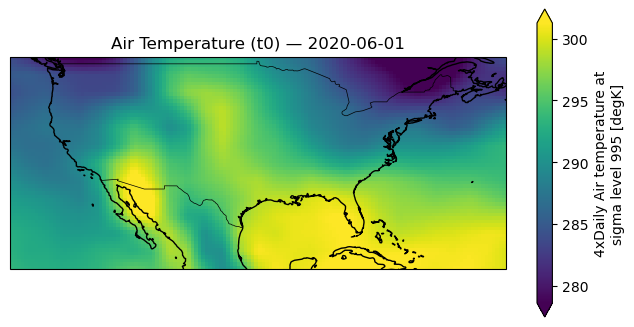

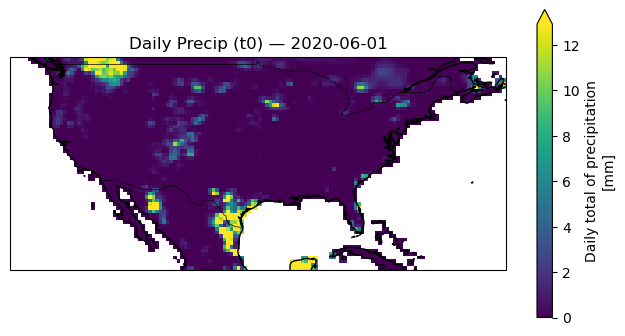

In [15]:
import matplotlib.pyplot as plt

first = merged.isel(time=0)

if ccrs is not None:
    proj = ccrs.PlateCarree()
    extent = [LON_RANGE_180[0], LON_RANGE_180[1], LAT_RANGE[0], LAT_RANGE[1]]

    # Air temperature
    fig = plt.figure(figsize=(8,5))
    ax = plt.axes(projection=proj)
    first["air_temperature"].plot(ax=ax, transform=proj, robust=True, cbar_kwargs={"shrink":0.8})
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_extent(extent, crs=proj)
    ax.set_title(f"Air Temperature (t0) — {str(first.time.values)[:10]}")
    plt.show()

    # Daily precip
    fig = plt.figure(figsize=(8,5))
    ax = plt.axes(projection=proj)
    first["daily_precip"].plot(ax=ax, transform=proj, robust=True, cbar_kwargs={"shrink":0.8})
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_extent(extent, crs=proj)
    ax.set_title(f"Daily Precip (t0) — {str(first.time.values)[:10]}")
    plt.show()
else:
    # Fallback: simple xarray plots without Cartopy
    first["air_temperature"].plot(robust=True)
    plt.title(f"Air Temperature (t0) — {str(first.time.values)[:10]}")
    plt.show()

    first["daily_precip"].plot(robust=True)
    plt.title(f"Daily Precip (t0) — {str(first.time.values)[:10]}")
    plt.show()


Pearson r (t0): 0.022


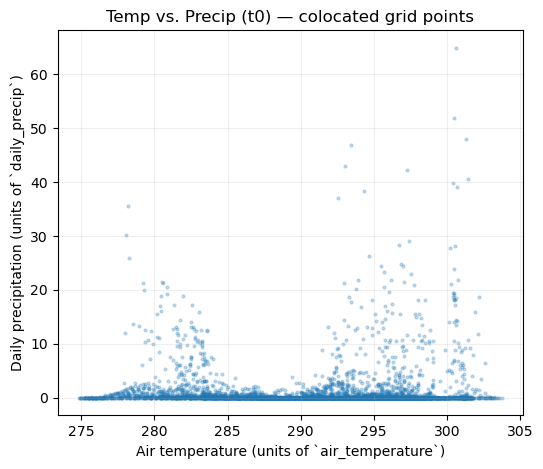

In [16]:
import numpy as np

first_stacked = first.stack(points=("lat", "lon")).dropna(dim="points")

x = first_stacked["air_temperature"].values
y = first_stacked["daily_precip"].values

plt.figure(figsize=(6,5))
plt.scatter(x, y, s=4, alpha=0.25)
plt.xlabel("Air temperature (units of `air_temperature`)")
plt.ylabel("Daily precipitation (units of `daily_precip`)")
plt.title("Temp vs. Precip (t0) — colocated grid points")
plt.grid(True, alpha=0.2)

# Quick correlation for reference
if x.size > 1 and y.size > 1:
    corr = np.corrcoef(x, y)[0,1]
    print(f"Pearson r (t0): {corr:.3f}")
plt.show()


In [17]:
# Add a couple of helpful attrs (optional)
merged.attrs.update({
    "title": "CONUS merged daily air temperature and precipitation (June 2020)",
    "source_temp": TEMP_URL,
    "source_precip": PRECIP_URL,
    "spatial_domain": "20–50N, 230–300E",
    "time_range": "2020-06-01 to 2020-06-30",
})

# Compression & dtype to keep size manageable
encoding = {
    "air_temperature": {"zlib": True, "complevel": 4, "dtype": "float32"},
    "daily_precip":    {"zlib": True, "complevel": 4, "dtype": "float32"},
}

out_path = "merged_conus_june2020.nc"
merged.to_netcdf(out_path, encoding=encoding)
print(f"Wrote {out_path}")


Wrote merged_conus_june2020.nc
